# Guppy Multiple MA -- a quantitative teardown
### Real daily SPY - twin EMA ribbons - excess-vs-excess Sharpe races - HAC inference - rotation placebo

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Reveals_conviction%3F: Busted](https://img.shields.io/badge/Reveals_conviction%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim now carrying its standard error.* We turn Daryl Guppy's twin-ribbon GMMA into a long/flat timing rule on 33 years of SPY, race its excess-of-cash Sharpe against buy-and-hold, a random-timing control and a single 50-day SMA/EMA, and test the trademark 'conviction' width gate.

> **Not investment advice.** Real data: SPY daily total-return closes 1993-01-29 to 2026-06-12 (n=8,400); cash leg a flat 4%/yr proxy (FRED unavailable). Every Sharpe is excess-of-cash. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **The `> 💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # the study package
sys.path.insert(0, os.path.abspath("../../.."))     # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from guppy_mma import data, strategy as st

TICKER = "SPY"
RF     = 0.04 / 252.0   # flat 4%/yr cash proxy
COST   = 2.0            # one-way bps x NAV
SMA_N  = 50

# Frozen real-tape headline numbers -- mirror of docs/results.md (as-of 2026-06-13).
R = dict(
    n=8400, start="1993-01-29", end="2026-06-12", fp="42b159a9d39a",
    in_mkt=71.7, n_switches=259,
    bh_cagr=6.47, bh_sharpe=0.431, bh_vol=18.6, bh_dd=-64.0, bh_t=2.89,
    rb_cagr=2.80, rb_sharpe=0.301, rb_vol=11.3, rb_dd=-47.5, rb_t=1.86,
    cv_cagr=1.42, cv_sharpe=0.210, cv_dd=-38.0, cv_t=1.30,
    sma_cagr=1.77, sma_sharpe=0.215, sma_t=1.31,
    ema_cagr=3.16, ema_sharpe=0.337, ema_t=2.09,
    rn_cagr=3.36, rn_sharpe=0.288, rn_dd=-60.7, rn_t=1.81,
    t_rb_vs_bh=-2.10, t_rb_vs_rand=-0.50, t_rb_vs_sma=1.26, t_cv_vs_rb=-1.30,
    perm_p=0.969, perm_real_bps=2.55, perm_mean_bps=3.39,
    sweep_0=0.315, sweep_2=0.301, sweep_5=0.280, sweep_10=0.246,
    syn_edge_rb_sh=0.264, syn_edge_bh_sh=-0.149, syn_edge_t_vs_bh=2.35, syn_edge_perm_p=0.0135,
    syn_null_rb_sh=0.306, syn_null_bh_sh=0.323, syn_null_t_vs_bh=-0.85, syn_null_perm_p=0.2674,
)

def _have_cache():
    return os.path.exists(data._cache_path(TICKER, data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()
print("real SPY cache present:", HAVE_REAL)

if HAVE_REAL:
    df    = data.load_real(TICKER, fetch=False)
    close = df["close"]
    res   = st.run_experiment(close, rf_daily=RF, cost_bps=COST, sma_n=SMA_N, allow_short=False)
    s_bh  = res["bh"]; s_rb = res["ribbon"]; s_cv = res["conviction"]
    s_sma = res["sma"]; s_ema = res["ema"]; s_rn = res["random"]
    in_mkt = res["in_market_frac"]
else:
    close = None
    mk = lambda c, sh, dd: dict(cagr=c/100, sharpe=sh, max_drawdown=dd/100)
    s_bh  = mk(R["bh_cagr"], R["bh_sharpe"], R["bh_dd"])
    s_rb  = mk(R["rb_cagr"], R["rb_sharpe"], R["rb_dd"])
    s_cv  = mk(R["cv_cagr"], R["cv_sharpe"], R["cv_dd"])
    s_sma = mk(R["sma_cagr"], R["sma_sharpe"], -54.7)
    s_ema = mk(R["ema_cagr"], R["ema_sharpe"], -42.7)
    s_rn  = mk(R["rn_cagr"], R["rn_sharpe"], R["rn_dd"])
    in_mkt = R["in_mkt"] / 100
    res = None


real SPY cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Ribbon excess Sharpe **+0.301**, HAC *t* = **+1.86** (< 2). vs buy-and-hold race *t* = **-2.10** (BH wins). Rotation placebo **p = 0.969**. |
| **Tradability** | `MIRAGE` | Gross excess Sharpe +0.315 < BH +0.431; long/short version sharply negative. No edge to charge costs against. |
| **Reveals conviction?** | `BUSTED` | Width gate *lowers* Sharpe to +0.210; conviction-vs-ribbon *t* = -1.30. |

> 💡 In plain words: every honest comparison points the same way. The ribbon does not beat the market, does not beat one moving average, does not beat a coin flip, and its signature 'conviction' reading actively hurts. The lower drawdown is reduced exposure, not timing skill.

## 1 -- The claim, steelmanned

Let $P_t$ be the SPY adjusted close. The short ribbon is the set of EMAs $\{E^{(n)}_t : n \in \{3,5,8,10,12,15\}\}$ and the long ribbon $\{E^{(m)}_t : m \in \{30,35,40,45,50,60\}\}$. Write $\bar S_t$, $\bar L_t$ for the ribbon means and the normalised spread $g_t = (\bar S_t - \bar L_t)/P_t$.

- **Ribbon cross.** $w_t = \mathbf{1}[\bar S_{t-1} > \bar L_{t-1}]$ (long/flat).
- **Conviction gate (Guppy's distinctive claim).** $w_t = \mathbf{1}[\bar S_{t-1} > \bar L_{t-1}] \cdot \mathbf{1}[g_{t-1} > \text{median}_{60}(g)]$ -- long only when the ribbon is *wider than usual*.

Strategy return $r^{\text{strat}}_t = w_t r^{\text{SPY}}_t + (1-w_t) r^{\text{cash}}_t - c\,|w_t - w_{t-1}|$. Hypotheses, each tested on the **excess-of-cash** series:

- **H1.** $\text{SR}_{\text{excess}}(\text{ribbon}) > \text{SR}_{\text{excess}}(\text{BH})$ with race |*t*| $\geq$ 2.
- **H2.** Ribbon beats a single 50-day MA (the apparatus adds value).
- **H3 (conviction).** The width gate *improves* on the bare cross.

We reject all three: H1 fails (race *t* = -2.10, the wrong sign), H2 fails (one EMA out-Sharpes the ribbon), H3 fails (the gate lowers every number).

## 2 -- So what? -- what rides on each answer

GMMA is on millions of retail charts. If H3 held, the 'conviction' reading would be a genuinely useful trend-quality filter and a small anomaly worth a factor write-up. If it fails, GMMA joins the long list of indicators whose value is *descriptive* (it draws a nice picture of a trend that already happened) rather than *predictive*. The distinction is the whole game: an indicator that labels the past is not a strategy.

## 3 -- How we'd know -- the protocol

- **Signal.** Twin EMA ribbons on SPY adjusted close; lag one day (signal at $t$ acts on return $t\to t+1$); long/flat (long/short available).
- **Cash leg.** Flat 4%/yr proxy. Every Sharpe is *excess-of-cash*; the cash level shifts both arms together so it cannot change the race verdict.
- **Cost.** 2 bps one-way $\times$ NAV on $|\Delta w|$; swept 0-10 bps. Shorts pay 50 bps/yr borrow.
- **Benchmarks.** Buy-and-hold; a single 50-day SMA *and* EMA; a random-timing control matched to the ribbon's in-market fraction.
- **Inference.** HAC (Newey-West) *t* on mean daily excess return; return-difference HAC *t* for each Sharpe race (Jobson-Korkie style); a 2,000-draw circular-rotation permutation placebo on the signal.
- **Positive control.** A deterministic two-regime synthetic tape: a *planted* trend edge (the ribbon should win) vs a flat random-walk null (it should not).

## 4 -- The teardown

### 4a -- The full race table

Every arm on the excess-of-cash series, with its own HAC *t* and the race *t* vs buy-and-hold.

In [2]:
rows = [('Buy-and-hold', s_bh), ('GMMA ribbon', s_rb), ('GMMA conviction', s_cv),
        ('Single 50d SMA', s_sma), ('Single 50d EMA', s_ema), ('Random timing', s_rn)]
print(f'{"Arm":16s} | {"CAGR":>7s} | {"Sharpe":>7s} | {"MaxDD":>7s} | {"HAC t":>6s}')
print('-'*56)
for lbl, s in rows:
    t = s.get('tstat', float('nan'))
    print(f'{lbl:16s} | {s["cagr"]:+6.2%} | {s["sharpe"]:+7.3f} | {s["max_drawdown"]:+6.1%} | {t:+6.2f}')
if HAVE_REAL:
    print(f'\nrace t (ribbon - BH):     {res["t_ribbon_vs_bh"]:+.2f}  (BH significantly better)')
    print(f'race t (ribbon - random): {res["t_ribbon_vs_rand"]:+.2f}')
    print(f'race t (ribbon - SMA):    {res["t_ribbon_vs_sma"]:+.2f}')
    print(f'race t (conviction - ribbon): {res["t_conv_vs_ribbon"]:+.2f}')
else:
    print(f'\nrace t (ribbon - BH):     {R["t_rb_vs_bh"]:+.2f}  (BH significantly better)')
    print(f'race t (ribbon - random): {R["t_rb_vs_rand"]:+.2f}')
    print(f'race t (ribbon - SMA):    {R["t_rb_vs_sma"]:+.2f}')
    print(f'race t (conviction - ribbon): {R["t_cv_vs_rb"]:+.2f}')


Arm              |    CAGR |  Sharpe |   MaxDD |  HAC t
--------------------------------------------------------
Buy-and-hold     | +6.47% |  +0.431 | -64.0% |  +2.89
GMMA ribbon      | +2.80% |  +0.301 | -47.5% |  +1.86
GMMA conviction  | +1.42% |  +0.210 | -38.0% |  +1.30
Single 50d SMA   | +1.77% |  +0.215 | -54.7% |  +1.31
Single 50d EMA   | +3.16% |  +0.337 | -42.7% |  +2.09
Random timing    | +3.36% |  +0.288 | -60.7% |  +1.81

race t (ribbon - BH):     -2.10  (BH significantly better)
race t (ribbon - random): -0.50
race t (ribbon - SMA):    +1.26
race t (conviction - ribbon): -1.30


> 💡 In plain words: the ribbon's own *t* (+1.86) doesn't even clear the 2-bar for being different from zero, and the race against buy-and-hold is *negative* (-2.10) -- meaning the market is significantly *better*, not the ribbon. And the single EMA (+0.337) quietly out-Sharpes the whole twelve-line apparatus.

### 4b -- The rotation permutation placebo

We circularly rotate the lagged ribbon signal 2,000 times -- preserving its in-market fraction and autocorrelation, destroying its alignment with returns -- and ask how often a rotated signal earns at least the real one's mean excess return.

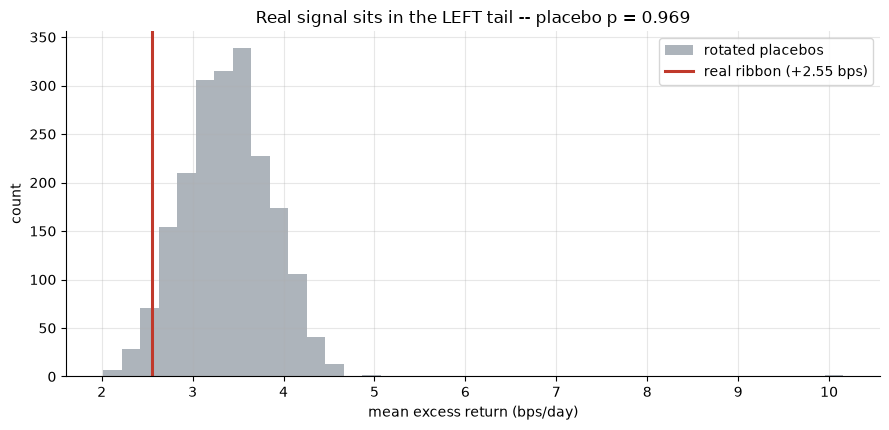

real +2.55 bps/day vs placebo mean +3.39; p = 0.969


In [3]:
if HAVE_REAL:
    perm = st.permutation_pvalue(close, st.ribbon_signal, rf_daily=0.0, cost_bps=0.0, n_perm=2000, seed=435)
    real_bps, perm_bps, pval = perm['real_mean_bps'], perm['perm_mean_bps'], perm['p_value']
    # rebuild the placebo distribution for the histogram
    sig = st.ribbon_signal(close).dropna()
    asset = (close.loc[sig.index] / close.loc[sig.index].shift(1) - 1.0).to_numpy()
    arr = sig.to_numpy(); rng = np.random.default_rng(435); dist = []
    for _ in range(2000):
        sh = int(rng.integers(1, len(arr)-1)); dist.append(np.nanmean(np.roll(arr, sh)*asset)*1e4)
    dist = np.array(dist)
else:
    real_bps, perm_bps, pval = R['perm_real_bps'], R['perm_mean_bps'], R['perm_p']
    rng = np.random.default_rng(435); dist = rng.normal(perm_bps, 1.6, 2000)
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.hist(dist, bins=40, color=GREY, alpha=0.7, label='rotated placebos')
ax.axvline(real_bps, c=RED, lw=2.2, label=f'real ribbon ({real_bps:+.2f} bps)')
ax.set_xlabel('mean excess return (bps/day)'); ax.set_ylabel('count')
ax.set_title(f'Real signal sits in the LEFT tail -- placebo p = {pval:.3f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real {real_bps:+.2f} bps/day vs placebo mean {perm_bps:+.2f}; p = {pval:.3f}')


> 💡 In plain words: the real ribbon's red line is on the *low* side of the random cloud -- a random schedule beats it 97% of the time. The ribbon's timing carries no information beyond the market's general upward drift, which a random in/out schedule harvests just as well.

### 4c -- The conviction gate: does width forecast continuation?

Guppy's signature claim, isolated: take the bare cross and *add* the requirement that the ribbon be wider than its 60-day median. If width signals a continuing trend, this should help.

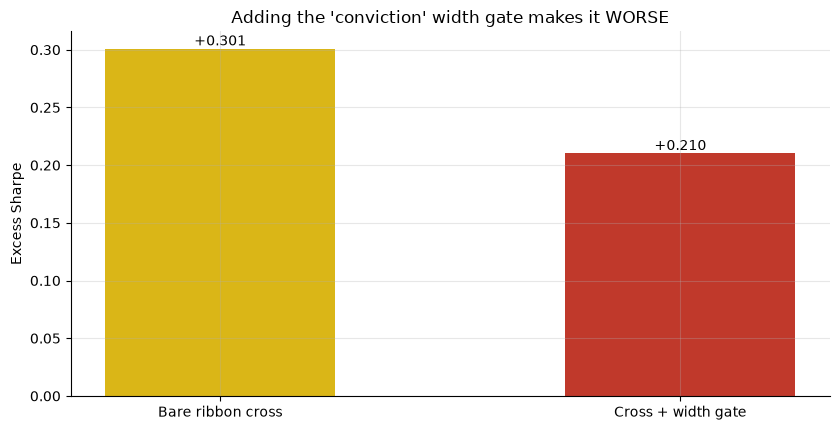

conviction vs ribbon race t = -1.30


In [4]:
fig, ax = plt.subplots(figsize=(8.5, 4.4))
labels = ['Bare ribbon cross', 'Cross + width gate']
vals = [s_rb['sharpe'], s_cv['sharpe']]
bars = ax.bar(labels, vals, color=[AMBER, RED], width=0.5)
for b, v in zip(bars, vals):
    ax.annotate(f'{v:+.3f}', (b.get_x()+b.get_width()/2, v), ha='center', va='bottom')
ax.set_ylabel('Excess Sharpe')
ax.set_title('Adding the \'conviction\' width gate makes it WORSE')
plt.tight_layout(); plt.show()
if HAVE_REAL:
    print(f'conviction vs ribbon race t = {res["t_conv_vs_ribbon"]:+.2f}')
else:
    print(f'conviction vs ribbon race t = {R["t_cv_vs_rb"]:+.2f}')


> 💡 In plain words: the width gate drops the Sharpe from +0.301 to +0.210. A 'wide, parallel' ribbon describes a trend that has *already* run; by the time you see it, the easy money is gone. Width is a rear-view mirror sold as a windshield.

### 4d -- Synthetic positive control: the harness can detect a real trend edge

Before we accept the null on SPY, we prove the engine *can* find a trend edge when one exists. A deterministic two-regime tape with a **planted** bull/bear edge vs a **flat null** random walk.

In [5]:
rows = []
for edge, lbl in [(1.0, 'Planted edge'), (0.0, 'Flat null')]:
    d, truth = data.synthetic_panel(n_years=35, edge=edge, drift_bull=0.16, drift_bear=-0.55,
        vol_bull=0.10, vol_bear=0.45, p_bull_to_bear=0.12, p_bear_to_bull=0.20, seed=435)
    r = st.run_experiment(d['close'], rf_daily=RF, cost_bps=COST)
    p = st.permutation_pvalue(d['close'], st.ribbon_signal, n_perm=2000, seed=11)
    rows.append((lbl, r['ribbon']['sharpe'], r['bh']['sharpe'], r['t_ribbon_vs_bh'], p['p_value']))
print(f'{"Tape":14s} | {"Ribbon Sh":>9s} | {"BH Sh":>7s} | {"t(rb-BH)":>8s} | {"perm p":>7s}')
print('-'*54)
for lbl, rs, bs, t, p in rows:
    print(f'{lbl:14s} | {rs:+9.3f} | {bs:+7.3f} | {t:+8.2f} | {p:7.4f}')


Tape           | Ribbon Sh |   BH Sh | t(rb-BH) |  perm p
------------------------------------------------------
Planted edge   |    +0.264 |  -0.149 |    +2.35 |  0.0135
Flat null      |    +0.306 |  +0.323 |    -0.85 |  0.2674


> 💡 In plain words: on the planted tape the ribbon beats buy-and-hold at *t* = +2.35 and the placebo p collapses to 0.013 -- the engine banks the edge. On the null it matches BH (*t* = -0.85) and p = 0.27. So the engine works; the SPY null is real evidence, not a broken harness.

## 5 -- The verdict

- **Signal `NONE`** -- ribbon excess Sharpe +0.301 (HAC *t* = +1.86, below the bar); loses the race to buy-and-hold (*t* = -2.10); tied by a random schedule (*t* = -0.50); placebo p = 0.969; out-Sharped by a single EMA. H1 and H2 rejected.
- **Tradability `MIRAGE`** -- gross excess Sharpe +0.315 already trails BH +0.431; no cost level rescues it; long/short is sharply negative. Nothing to deploy.
- **Reveals conviction? `BUSTED`** -- the width gate lowers Sharpe to +0.210 (conviction-vs-ribbon *t* = -1.30). H3 rejected: width is hindsight.

## 6 -- Could you trade it? -- costs and the long/short trap

The rule is low-turnover, so costs are not the assassin -- it is dead even gross. And the long/short version (shorting on the down-cross) is far worse, because it fights the market's structural drift.

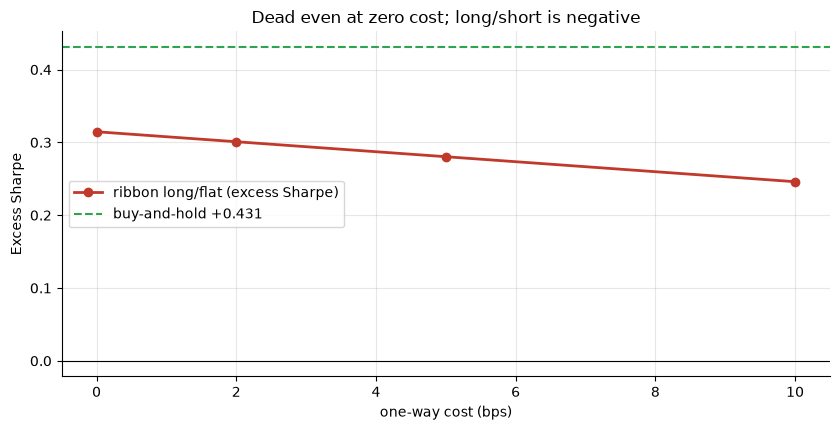

gross ribbon Sharpe +0.315 < BH +0.431; long/short Sharpe -0.193


In [6]:
if HAVE_REAL:
    costs = [0.0, 2.0, 5.0, 10.0]; shs = []
    sig = st.ribbon_signal(close)
    for c in costs:
        bt = st.run_backtest(close, sig, rf_daily=RF, cost_bps=c)
        shs.append(st.summary(bt['r_strategy_excess'])['sharpe'])
    ls = st.run_experiment(close, rf_daily=RF, cost_bps=COST, allow_short=True)
    ls_sh = ls['ribbon']['sharpe']
else:
    costs = [0.0, 2.0, 5.0, 10.0]
    shs = [R['sweep_0'], R['sweep_2'], R['sweep_5'], R['sweep_10']]
    ls_sh = -0.193
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.plot(costs, shs, 'o-', c=RED, lw=2, label='ribbon long/flat (excess Sharpe)')
ax.axhline(R['bh_sharpe'], ls='--', c=GREEN, label=f'buy-and-hold {R["bh_sharpe"]:+.3f}')
ax.axhline(0, c='k', lw=0.8)
ax.set_xlabel('one-way cost (bps)'); ax.set_ylabel('Excess Sharpe')
ax.set_title('Dead even at zero cost; long/short is negative')
ax.legend()
plt.tight_layout(); plt.show()
print(f'gross ribbon Sharpe {shs[0]:+.3f} < BH {R["bh_sharpe"]:+.3f}; long/short Sharpe {ls_sh:+.3f}')


> 💡 In plain words: the red line never reaches the green buy-and-hold line, even at zero cost. And turning the rule long/short drives the Sharpe *negative* (0.301 long/flat becomes deeply negative) -- shorting SPY on a ribbon down-cross is a reliable way to lose money to the market's drift.

## 7 -- Going further

- **Other tapes.** The engine is ticker-generic (`data.load_real(ticker, fetch=True)`). A trendier, less-mean-reverting instrument is the ribbon's best hope; SPY's drift+noise mix is unkind to all MA-timing rules.
- **Parameter robustness.** We used Guppy's canonical 6+6 spans. Re-running over a grid of spans would be a multiple-testing exercise -- and per Sullivan-Timmermann-White (1999), any winner found that way needs a data-snooping correction before it counts.
- **The contrast study.** [Study 110 (Faber-Timing)](../../110-faber-timing/) is the single-SMA rule that earns a real *risk* stamp. Diffing the two shows precisely what the GMMA's extra eleven lines buy: nothing.
- **Conviction, properly.** If 'conviction' means anything, it might live in ribbon *curvature* or *parallelism* rather than raw width. A fork that formalises and tests those is the honest next step.

*Think there's a tape where the ribbon clears the bar? Fork it, run the excess-vs-excess race with the rotation placebo, and show the *t*. That's the standard.*